# Allocator Selection: Crypto Perpetual Futures

Does portfolio weighting improve the selected funding-aligned carrier, and does the answer survive
explicit funding settlement? This notebook reads the frozen allocation sweep, identifies its
validation leader, and replays every semantic allocation cell without registration. The replay
preserves predictions, entry rules, and orders while adding official Binance funding cash flows.

**Learning objectives**

- Interpret the allocation stage as a validation-only comparison over baseline survivors
- Distinguish stored price P&L from perpetual-futures total return
- Reconstruct each registered allocator specification without changing the registry
- Test whether funding settlement changes the allocator winner

**Book reference**: Chapter 17, Portfolio Construction

**Prerequisites**: [`13_backtest`](13_backtest.ipynb) and a completed allocation sweep in
`run_log/registry.db`

In [1]:
"""Read-only allocator analysis with official funding settlement."""

import json
import sqlite3
import warnings
from collections import defaultdict
from datetime import UTC, datetime

import numpy as np
import plotly.graph_objects as go
import polars as pl

from case_studies.crypto_perps_funding.funding_data import load_funding_rates
from case_studies.utils.backtest_loaders import (
    get_backtest_config,
    load_backtest_prices_for,
    warmup_periods_for,
)
from case_studies.utils.backtest_presets import build_backtest_spec
from case_studies.utils.backtest_runner import precompute_weights, run_backtest
from case_studies.utils.conformal import compute_conformal_widths
from case_studies.utils.cv_window import canonical_window
from case_studies.utils.registry import read_predictions
from utils.paths import get_case_study_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS

In [2]:
CASE_STUDY = "crypto_perps_funding"
SEED = 42
BAR_HOURS = 8
MAX_SYMBOLS = 0
TOP_N_PREDICTIONS = None
CONFORMAL_ALPHA = 0.20
EXPECTED_ALLOCATORS = (
    "conformal_weighted",
    "equal_weight",
    "hrp",
    "inverse_vol",
    "mvo_ledoit_wolf",
    "risk_parity",
    "score_weighted",
)

In [3]:
set_global_seeds(SEED)
FROZEN_CASE_DIR = get_case_study_dir(CASE_STUDY, create=False)
REGISTRY_PATH = FROZEN_CASE_DIR / "run_log" / "registry.db"
config = get_backtest_config(CASE_STUDY)

print(f"Registry: {REGISTRY_PATH.name} (read-only analysis)")
print(f"Round-trip trading cost: {config.commission_bps + config.slippage_bps:.1f} bps")

Registry: registry.db (read-only analysis)
Round-trip trading cost: 5.0 bps


## Freeze the validation leaders

The allocation sweep receives model configurations selected at the equal-weight baseline. It never
sees the sealed holdout. The frozen cohort table below includes selection-aware DSR over every
registered allocation variant for each label.

In [4]:
def _allocation_leaders(registry_path) -> pl.DataFrame:
    """Return one frozen allocation-stage leader per label."""
    query = """
        SELECT c.label, t.family, t.config_name, p.checkpoint_value,
               b.prediction_hash, b.backtest_hash, b.spec_json,
               c.k_variants, c.dsr_er_pvalue, c.computed_at,
               m.sharpe, m.sharpe_ci95_lo, m.sharpe_ci95_hi,
               m.cagr, m.max_drawdown
        FROM cohort_metrics c
        JOIN backtest_runs b ON b.backtest_hash = c.leader_hash
        JOIN backtest_metrics m USING (backtest_hash)
        JOIN prediction_sets p USING (prediction_hash)
        JOIN training_runs t USING (training_hash)
        WHERE c.cohort_type = 'stagelabel' AND c.stage = 'allocation'
        ORDER BY c.label
    """
    with sqlite3.connect(f"file:{registry_path}?mode=ro", uri=True) as connection:
        return pl.read_database(query, connection)

In [5]:
leaders = _allocation_leaders(REGISTRY_PATH)
if leaders.height != 4:
    raise RuntimeError(f"Expected four label-level allocation leaders, found {leaders.height}")

leader_allocations = [json.loads(value)["strategy"]["allocation"] for value in leaders["spec_json"]]
leaders = leaders.with_columns(
    pl.Series("allocator", [value["method"] for value in leader_allocations]),
    pl.Series("top_k", [value.get("top_k") for value in leader_allocations], dtype=pl.Int64),
    (pl.col("family") + pl.lit("/") + pl.col("config_name")).alias("source"),
)
print(
    leaders.select(
        "label",
        "source",
        "allocator",
        "top_k",
        "k_variants",
        "sharpe",
        "sharpe_ci95_lo",
        "sharpe_ci95_hi",
        "dsr_er_pvalue",
    )
)

shape: (4, 9)
┌────────────┬────────────┬────────────┬───────┬───┬───────────┬───────────┬───────────┬───────────┐
│ label      ┆ source     ┆ allocator  ┆ top_k ┆ … ┆ sharpe    ┆ sharpe_ci ┆ sharpe_ci ┆ dsr_er_pv │
│ ---        ┆ ---        ┆ ---        ┆ ---   ┆   ┆ ---       ┆ 95_lo     ┆ 95_hi     ┆ alue      │
│ str        ┆ str        ┆ str        ┆ i64   ┆   ┆ f64       ┆ ---       ┆ ---       ┆ ---       │
│            ┆            ┆            ┆       ┆   ┆           ┆ f64       ┆ f64       ┆ f64       │
╞════════════╪════════════╪════════════╪═══════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ fwd_dir_8h ┆ linear/log ┆ inverse_vo ┆ 10    ┆ … ┆ -0.796366 ┆ -2.807298 ┆ 0.77532   ┆ 0.999996  │
│            ┆ istic_l2_C ┆ l          ┆       ┆   ┆           ┆           ┆           ┆           │
│            ┆ 0.001      ┆            ┆       ┆   ┆           ┆           ┆           ┆           │
│ fwd_dir_8h ┆ linear/log ┆ hrp        ┆ 5     ┆ … ┆ -0.878444 ┆ -2.303396 ┆ 

## Only the 24-hour return lineage survives allocation selection

Three label-specific confidence intervals cross or remain below zero. The 24-hour return lineage
is the sole positive allocation-stage leader, and it is the carrier examined below.

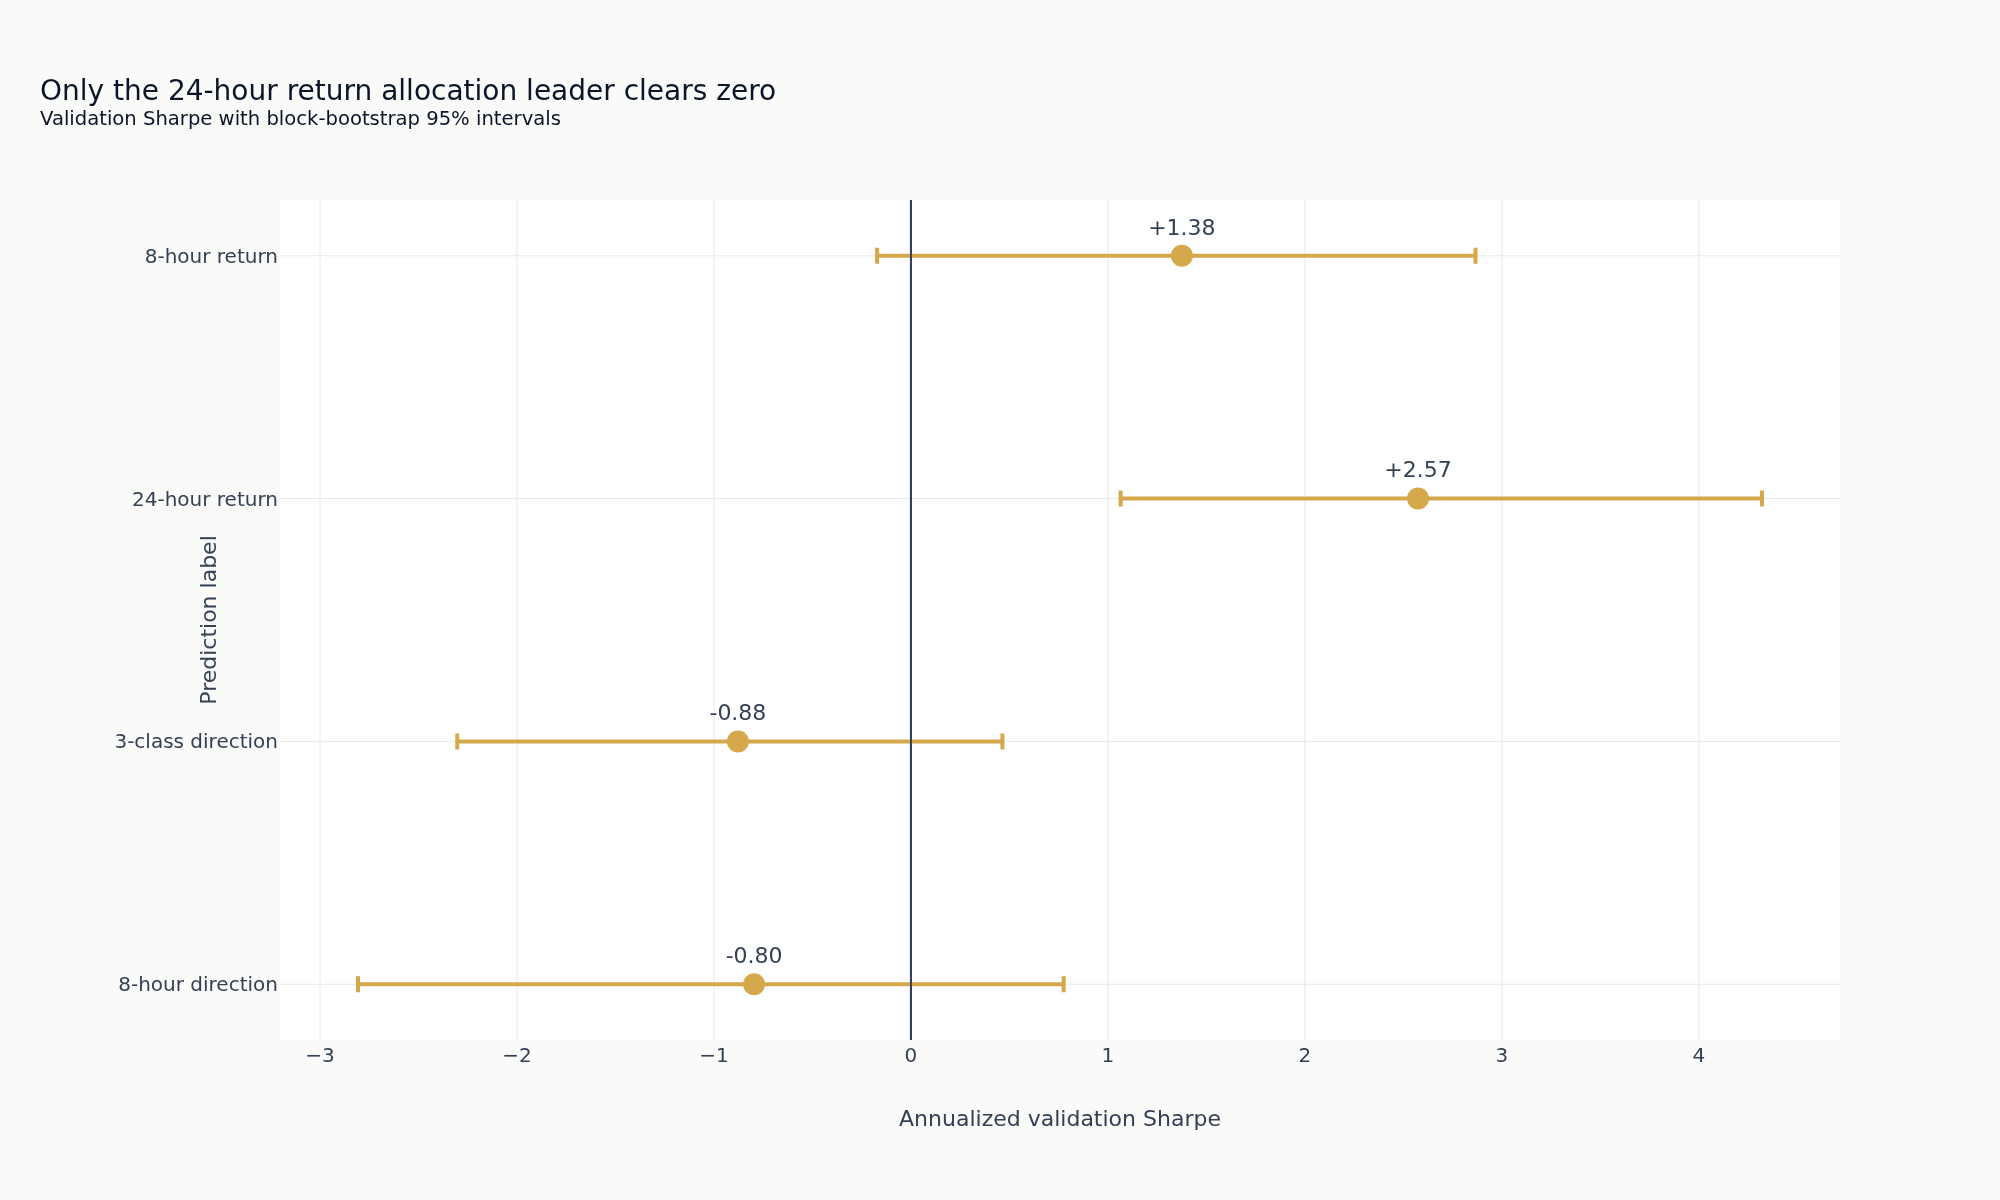

In [6]:
label_names = {
    "fwd_dir_8h": "8-hour direction",
    "fwd_dir_8h_3c": "3-class direction",
    "fwd_ret_8h": "8-hour return",
    "fwd_ret_24h": "24-hour return",
}
fig = go.Figure(
    go.Scatter(
        x=leaders["sharpe"],
        y=[label_names[value] for value in leaders["label"]],
        mode="markers+text",
        text=[f"{value:+.2f}" for value in leaders["sharpe"]],
        textposition="top center",
        marker={"size": 11, "color": COLORS["amber"]},
        error_x={
            "type": "data",
            "symmetric": False,
            "array": (leaders["sharpe_ci95_hi"] - leaders["sharpe"]).to_list(),
            "arrayminus": (leaders["sharpe"] - leaders["sharpe_ci95_lo"]).to_list(),
        },
    )
)
fig.add_vline(x=0, line_color=COLORS["neutral"], line_width=1)
fig.update_layout(
    title={
        "text": "Only the 24-hour return allocation leader clears zero"
        "<br><sup>Validation Sharpe with block-bootstrap 95% intervals</sup>",
        "x": 0.02,
        "xanchor": "left",
    },
    xaxis_title="Annualized validation Sharpe",
    yaxis_title="Prediction label",
    showlegend=False,
    margin={"l": 140},
)
fig.show()

## Reconstruct the selected allocation grid

The winning cohort row fixes the model, checkpoint, and prediction hash before allocator analysis.
Several specifications carry more than one registered row - reruns of the same specification, and
reparameterizations of a declared allocator that the strategy spec records but the design does not
distinguish - so the query collapses them to one semantic `(allocator, top_k, lookback)` cell and
reads the best stored Sharpe in it. No result is ranked on the holdout.

How many physical rows that is, is not a property of the design: a rerun adds one without changing
the grid, and this carrier has two rows for most of its cells for exactly that reason. What the
design fixes is the set of semantic cells, and the assertion two cells down requires exactly that
set in both directions, so a stray allocator or concentration fails closed while a rerun does not.

The collapse reads the best stored Sharpe in a cell, which is safe for a rerun of one specification
and not safe for a different one. Rows have been written against this carrier after the cohort
metrics below were computed, and they are not among the `k_variants` trials those metrics correct
for ([#63](https://github.com/ml4t/agent-workspace/issues/63)), so a later reparameterization that
happened to score well could take a cell away from the specification that was actually trialled.
A row registered after the cohort is therefore admitted only when the cohort already trialled its
exact specification - which is what a rerun is, and what a reparameterization is not.

`created_at` is the evidence for "already trialled", and it is not immutable: re-registering an
identical specification rewrites the row and resets it. That direction fails safe - the cell loses
its pre-cohort evidence, the row is excluded, and the grid assertion below reports a missing cell
rather than admitting anything. Persisting the cohort's member hashes when it is computed would
remove the dependence entirely, and is the durable fix (#63).

In [7]:
carrier = leaders.sort("sharpe", descending=True).row(0, named=True)
if carrier["label"] != "fwd_ret_24h":
    raise RuntimeError("The frozen allocation winner changed; review the 24-hour carrier narrative")
CARRIER_LABEL = carrier["label"]
CARRIER_PREDICTION = carrier["prediction_hash"]
if CARRIER_PREDICTION != "fb85a7d19ce1":
    raise RuntimeError("The frozen v3.0 carrier identity changed")

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="'Y' is deprecated", category=FutureWarning)
    validation_window = canonical_window(CASE_STUDY, CARRIER_LABEL, split="validation")
if validation_window is None:
    raise RuntimeError("No canonical validation window for the selected carrier")
validation_start, validation_end = validation_window

print(
    f"Carrier: {carrier['source']} checkpoint={carrier['checkpoint_value']} "
    f"prediction={CARRIER_PREDICTION}"
)
print(f"Validation window: {validation_start} through {validation_end}")

Carrier: gbm/leaves_7_huber checkpoint=500 prediction=fb85a7d19ce1
Validation window: 2022-01-03 through 2023-12-31


In [8]:
def _spec_identity(spec_json: str) -> str:
    """The stored specification, less what does not define it.

    Provenance keys are dropped: the registry writes `_runtime_backtest_config` as a repr
    carrying absolute paths. Null values are dropped with them, because the serializer has
    gained explicitly-null keys over time - `margin_pct_schedule` appeared between the
    2026-05 sweep and its 2026-06 reruns - and an absent key and a null one say the same
    thing. Everything else is compared, so a changed commission, slippage, execution or
    feed setting reads as a different specification rather than as a rerun.
    """

    def prune(value):
        if isinstance(value, dict):
            return {
                key: prune(item)
                for key, item in sorted(value.items())
                if item is not None and not key.startswith("_")
            }
        return value

    return json.dumps(prune(json.loads(spec_json)), sort_keys=True)


def _allocation_cells(registry_path, prediction_hash: str, frozen_as_of: str) -> list[dict]:
    """Return one stored specification per semantic allocation cell of the frozen trial set."""
    query = """
        SELECT b.backtest_hash, b.created_at, b.spec_json, m.sharpe
        FROM backtest_runs b JOIN backtest_metrics m USING (backtest_hash)
        WHERE b.stage = 'allocation' AND b.prediction_hash = ?
    """
    with sqlite3.connect(f"file:{registry_path}?mode=ro", uri=True) as connection:
        rows = connection.execute(query, (prediction_hash,)).fetchall()
    frozen_specs = {
        _spec_identity(spec_json)
        for _, created_at, spec_json, _ in rows
        if created_at <= frozen_as_of
    }
    admitted = [
        row for row in rows if row[1] <= frozen_as_of or _spec_identity(row[2]) in frozen_specs
    ]
    if len(admitted) < len(rows):
        print(
            f"Excluded {len(rows) - len(admitted)} allocation row(s) registered after the frozen "
            f"cohort under a specification it never trialled"
        )
    cells = {}
    for backtest_hash, _, spec_json, stored_sharpe in admitted:
        strategy = json.loads(spec_json)["strategy"]
        signal = strategy["signal"]
        allocation = strategy["allocation"]
        key = (
            allocation["method"],
            allocation.get("top_k"),
            allocation.get("vol_window"),
            allocation.get("lookback"),
            signal["method"],
            signal.get("top_k"),
        )
        if key not in cells or stored_sharpe > cells[key]["stored_sharpe"]:
            cells[key] = {
                "backtest_hash": backtest_hash,
                "signal": signal,
                "allocation": allocation,
                "stored_sharpe": stored_sharpe,
            }
    return [cells[key] for key in sorted(cells)]

In [9]:
cells = _allocation_cells(REGISTRY_PATH, CARRIER_PREDICTION, carrier["computed_at"])
allocator_names = sorted({cell["allocation"]["method"] for cell in cells})
top_k_values = sorted({cell["allocation"].get("top_k") for cell in cells})
observed_grid = {(cell["allocation"]["method"], cell["allocation"].get("top_k")) for cell in cells}
expected_grid = {(allocator, top_k) for allocator in set(EXPECTED_ALLOCATORS) for top_k in {5, 10}}
if len(cells) != len(expected_grid) or observed_grid != expected_grid:
    raise RuntimeError(
        f"The registered allocation grid is not the declared one: expected {len(expected_grid)} "
        f"cells {sorted(expected_grid)}, found {len(cells)} cells {sorted(observed_grid)}"
    )
print(
    f"Semantic allocation grid: {len(cells)} cells across {len(allocator_names)} allocators "
    f"and {len(top_k_values)} concentrations"
)

Semantic allocation grid: 14 cells across 7 allocators and 2 concentrations


## Put the frozen artifact on its availability clock

The v3.0 prediction artifact stores the legacy bar-open timestamp. Its target is first checked
against current raw prices. Predictions and prices are then advanced together by one completed
8-hour bar, preserving the economic pair while moving execution to the declared funding timestamp.

In [10]:
frozen_predictions = read_predictions(CASE_STUDY, CARRIER_PREDICTION, case_dir=FROZEN_CASE_DIR)
raw_prices = load_backtest_prices_for(
    CASE_STUDY,
    CARRIER_LABEL,
    split="validation",
    max_symbols=MAX_SYMBOLS,
    warmup_periods=warmup_periods_for(CASE_STUDY),
)
legacy_targets = (
    raw_prices.sort("symbol", "timestamp")
    .with_columns(
        pl.col("close").shift(-3).over("symbol").alias("end_close"),
        pl.col("timestamp").shift(-3).over("symbol").alias("end_timestamp"),
    )
    .filter(pl.col("end_timestamp") == pl.col("timestamp") + pl.duration(hours=24))
    .select(
        pl.col("timestamp").dt.replace_time_zone("UTC"),
        "symbol",
        (pl.col("end_close") / pl.col("close") - 1).alias("current_raw_target"),
    )
)
alignment = frozen_predictions.join(legacy_targets, on=["timestamp", "symbol"], how="inner")
target_correlation = alignment.select(pl.corr("y_true", "current_raw_target")).item()
if target_correlation < 0.99:
    raise ValueError("Frozen prediction timestamps do not match the legacy raw-price clock")
print(f"Frozen target/current raw-price correlation: {target_correlation:.6f}")

Frozen target/current raw-price correlation: 0.999452


In [11]:
predictions = frozen_predictions.with_columns(
    pl.col("timestamp") + pl.duration(hours=BAR_HOURS)
).filter(pl.col("timestamp").dt.date() <= validation_end)
prices = raw_prices.with_columns(pl.col("timestamp") + pl.duration(hours=BAR_HOURS)).filter(
    pl.col("timestamp").dt.date() <= validation_end
)
funding = (
    load_funding_rates(symbols=prices["symbol"].unique().to_list())
    .with_columns(pl.col("timestamp").cast(prices.schema["timestamp"]))
    .filter(
        (pl.col("timestamp") >= prices["timestamp"].min())
        & (pl.col("timestamp") <= prices["timestamp"].max())
    )
)
print(
    f"Predictions: {predictions.height:,}; prices: {prices.height:,}; "
    f"official settlements: {funding.height:,}"
)

Predictions: 31,824; prices: 42,255; official settlements: 42,395


## Require point-in-time conformal calibration

Conformal sizing is valid only when each validation fold uses residuals from earlier validation
folds. The earliest fold has no such residuals and must be absent. The replay recomputes the
expected widths without writing and refuses any persisted artifact that differs.

In [12]:
if "conformal_weighted" in EXPECTED_ALLOCATORS:
    fold_order = (
        frozen_predictions.group_by("fold_id")
        .agg(pl.col("timestamp").min().alias("start"))
        .sort("start")["fold_id"]
        .to_list()
    )
    earliest_fold = fold_order[0]
    conformal_path = (
        FROZEN_CASE_DIR
        / "run_log"
        / "predictions"
        / CARRIER_PREDICTION
        / "conformal_widths.parquet"
    )
    if not conformal_path.exists():
        raise FileNotFoundError(f"Missing precomputed conformal widths: {conformal_path}")
    persisted_widths = (
        pl.read_parquet(conformal_path)
        .filter(pl.col("alpha") == CONFORMAL_ALPHA)
        .filter(pl.col("fold_id") != earliest_fold)
        .sort("timestamp", "symbol")
    )
    expected_widths = (
        compute_conformal_widths(
            CASE_STUDY,
            CARRIER_PREDICTION,
            alpha=CONFORMAL_ALPHA,
            write=False,
            case_dir=FROZEN_CASE_DIR,
        )
        .filter(pl.col("fold_id") != earliest_fold)
        .sort("timestamp", "symbol")
    )
    if not persisted_widths.equals(expected_widths):
        raise RuntimeError("Persisted conformal widths are not point-in-time safe")
    width_folds = sorted(expected_widths["fold_id"].unique().to_list())
    if earliest_fold in width_folds:
        raise RuntimeError("The earliest validation fold cannot have conformal widths")
    print(
        f"PIT-safe conformal widths: {expected_widths.height:,} rows; "
        f"calibrated folds={width_folds}; omitted earliest fold={earliest_fold}"
    )
else:
    print("PIT-safe conformal validation: no conformal cell in the configured reduced surface")

PIT-safe conformal widths: 16,023 rows; calibrated folds=[0]; omitted earliest fold=1


A rank-based long-short request cannot admit more than half the available cross-section on either
side. The corrected replay caps each side at `floor(n_assets / 2)` at every timestamp. Frozen v3.0
values remain visible as history, including cells generated before this repair.

In [13]:
panel_sizes = predictions.group_by("timestamp").len().rename({"len": "n_assets"})
correction_rows = []
for top_k in top_k_values:
    correction_rows.append(
        {
            "requested_top_k": top_k,
            "capped_timestamps": panel_sizes.filter(pl.col("n_assets") < 2 * top_k).height,
        }
    )
corrections = pl.DataFrame(correction_rows).sort("requested_top_k")
print(
    f"Corrected allocation cells: {len(cells)}; panel size range: "
    f"{panel_sizes['n_assets'].min()} to {panel_sizes['n_assets'].max()}"
)
print(corrections)

Corrected allocation cells: 14; panel size range: 5 to 19
shape: (2, 2)
┌─────────────────┬───────────────────┐
│ requested_top_k ┆ capped_timestamps │
│ ---             ┆ ---               │
│ i64             ┆ i64               │
╞═════════════════╪═══════════════════╡
│ 5               ┆ 186               │
│ 10              ┆ 1955              │
└─────────────────┴───────────────────┘


## Add funding to the carried position

Funding at time $t$ belongs to the position held into $t$. Orders filled at $t$ earn or pay the next
settlement. Temporary off-grid settlements use the last observable mark and carried position. The
accounting oracle reconstructs the engine's price-only equity from fills and marks before adding
funding as a separate cash component.

In [14]:
def _as_utc(value: datetime) -> datetime:
    """Normalize an engine timestamp to timezone-aware UTC."""
    return value.replace(tzinfo=UTC) if value.tzinfo is None else value.astimezone(UTC)

In [15]:
def _replay_inputs(result, price_frame: pl.DataFrame, funding_frame: pl.DataFrame):
    """Index fills, settlements, prices, and engine equity by UTC timestamp."""
    engine = result.engine_result
    if engine is None:
        raise RuntimeError("Funding replay requires an uncached engine result")

    fills = defaultdict(list)
    for fill in engine.fills:
        fills[_as_utc(fill.timestamp)].append(fill)
    rates = defaultdict(dict)
    for row in funding_frame.iter_rows(named=True):
        rates[_as_utc(row["timestamp"])][row["symbol"]] = float(row["funding_rate"])
    marks = defaultdict(dict)
    for row in price_frame.select("timestamp", "symbol", "close").iter_rows(named=True):
        marks[_as_utc(row["timestamp"])][row["symbol"]] = float(row["close"])
    equity = {_as_utc(ts): float(value) for ts, value in engine.equity_curve}
    return fills, rates, marks, equity

In [16]:
def _settlement_cash(positions, last_marks, timestamp_rates) -> float:
    """Calculate funding cash for the position carried into a settlement."""
    return sum(
        -(positions.get(symbol, 0.0) * last_marks[symbol]) * rate
        for symbol, rate in timestamp_rates.items()
        if positions.get(symbol, 0.0) != 0 and symbol in last_marks
    )

In [17]:
def _apply_fills(cash: float, positions, last_marks, timestamp_fills) -> float:
    """Apply fills after funding at a shared timestamp."""
    for fill in timestamp_fills:
        quantity = float(fill.quantity) if fill.side.value == "buy" else -float(fill.quantity)
        cash -= quantity * float(fill.price) + float(fill.commission)
        last_marks.setdefault(fill.asset, float(fill.price))
        positions[fill.asset] += quantity
        if abs(positions[fill.asset]) < 1e-12:
            del positions[fill.asset]
    return cash

In [18]:
def _replay_equity(result, price_frame: pl.DataFrame, funding_frame: pl.DataFrame):
    """Return funding-adjusted equity, cash flow, events, and reconstruction error."""
    fills, rates, marks, engine_equity = _replay_inputs(result, price_frame, funding_frame)

    cash = float(config.initial_cash)
    positions = defaultdict(float)
    cumulative_funding = 0.0
    events = 0
    settlements_processed = 0
    adjusted = []
    reconstructed = []
    last_marks = {}
    timeline = sorted(set(engine_equity) | set(rates))
    for timestamp in timeline:
        last_marks.update(marks[timestamp])
        timestamp_rates = rates.get(timestamp, {})
        settlements_processed += len(timestamp_rates)
        event_cash = _settlement_cash(positions, last_marks, timestamp_rates)
        if event_cash:
            cash += event_cash
            cumulative_funding += event_cash
            events += 1
        cash = _apply_fills(cash, positions, last_marks, fills.get(timestamp, []))
        if timestamp in engine_equity:
            marked = sum(quantity * last_marks[symbol] for symbol, quantity in positions.items())
            adjusted.append((timestamp, cash + marked))
            reconstructed.append((timestamp, cash - cumulative_funding + marked))

    error = max(abs(value - engine_equity[ts]) for ts, value in reconstructed)
    expected_settlements = sum(len(values) for values in rates.values())
    if settlements_processed != expected_settlements:
        raise RuntimeError("Funding replay did not consume every official settlement exactly once")
    return adjusted, cumulative_funding, events, error, settlements_processed

In [19]:
def _daily_sharpe(equity_curve: list[tuple[datetime, float]]) -> float:
    """Compute crypto-calendar Sharpe from end-of-day equity."""
    daily = (
        pl.DataFrame(equity_curve, schema=["timestamp", "equity"], orient="row")
        .with_columns(pl.col("timestamp").dt.date().alias("date"))
        .group_by("date")
        .agg(pl.col("equity").sort_by("timestamp").last())
        .sort("date")
        .with_columns(pl.col("equity").pct_change().alias("return"))
        .filter((pl.col("date") >= validation_start) & (pl.col("date") <= validation_end))
    )
    values = daily["return"].drop_nulls().to_numpy()
    return float(values.mean() / values.std(ddof=1) * np.sqrt(365))

Each replay passes the exact registered signal and allocation dictionaries to the engine with
`register=False`. Precomputed target weights are sorted by timestamp and symbol so cash-constrained
fills have a deterministic order. The stored and current price-only Sharpes differ slightly because
the current environment reruns floating-point allocation code; funding is evaluated against that
same current order stream.

In [20]:
def _run_registered_allocation(cell: dict):
    """Run one frozen allocation specification with deterministic target order."""
    allocation = cell["allocation"]
    spec = build_backtest_spec(
        CASE_STUDY,
        config,
        prices=prices,
        prediction_hash=CARRIER_PREDICTION,
        initial_cash=config.initial_cash,
        chapter="ch17",
        signal=cell["signal"],
        allocation=allocation,
    )
    weights = precompute_weights(
        predictions,
        spec,
        prices,
        label=CARRIER_LABEL,
        case_study=CASE_STUDY,
        prediction_hash=CARRIER_PREDICTION,
        conformal_widths=(
            expected_widths if allocation["method"] == "conformal_weighted" else None
        ),
    ).sort("timestamp", "symbol")
    return run_backtest(
        CASE_STUDY,
        CARRIER_PREDICTION,
        spec,
        prices=prices,
        predictions=predictions,
        label=CARRIER_LABEL,
        register=False,
        precomputed_weights=weights,
        initial_cash=config.initial_cash,
        calendar=config.calendar,
    )

In [21]:
def _replay_cell(cell: dict) -> dict:
    """Add official funding settlement to one frozen allocation cell."""
    allocation = cell["allocation"]
    result = _run_registered_allocation(cell)
    curve, funding_pnl, events, reconstruction_error, settlements_processed = _replay_equity(
        result, prices, funding
    )
    return {
        "allocator": allocation["method"],
        "top_k": allocation.get("top_k"),
        "stored_sharpe": cell["stored_sharpe"],
        "price_only_sharpe": float(result.metrics["sharpe"]),
        "with_funding_sharpe": _daily_sharpe(curve),
        "funding_pnl": funding_pnl,
        "funding_events": events,
        "settlements_processed": settlements_processed,
        "reconstruction_error": reconstruction_error,
    }

In [22]:
replay_rows = []
for index, cell in enumerate(cells, start=1):
    row = _replay_cell(cell)
    replay_rows.append(row)
    print(
        f"[{index:02d}/{len(cells)}] {row['allocator']} top_k={row['top_k']}: "
        f"price={row['price_only_sharpe']:+.3f} funding_pnl=${row['funding_pnl']:+,.0f}"
    )

replay = pl.DataFrame(replay_rows).sort("with_funding_sharpe", descending=True)
for metric in ("price_only_sharpe", "with_funding_sharpe", "funding_pnl"):
    if not replay[metric].is_finite().all():
        raise RuntimeError(f"Non-finite replay metric: {metric}")
reconstruction_errors = replay["reconstruction_error"]
if not reconstruction_errors.is_finite().all() or reconstruction_errors.max() > 1e-6:
    raise RuntimeError("Fill-and-mark reconstruction does not match engine equity")
if replay.filter(pl.col("settlements_processed") != funding.height).height:
    raise RuntimeError("At least one replay missed an official funding row")
print(f"Official settlement rows processed exactly once per replay: {funding.height:,}")
print(
    replay.select(
        "allocator",
        "top_k",
        "stored_sharpe",
        "price_only_sharpe",
        "with_funding_sharpe",
        "funding_pnl",
    )
)
for row in replay.iter_rows(named=True):
    print(
        f"{row['allocator']} requested_top_k={row['top_k']}: "
        f"price_only={row['price_only_sharpe']:+.6f}, "
        f"with_funding={row['with_funding_sharpe']:+.6f}, "
        f"funding_pnl=${row['funding_pnl']:+,.2f}"
    )

[01/14] conformal_weighted top_k=5: price=+0.088 funding_pnl=$+3,378


[02/14] conformal_weighted top_k=10: price=-0.500 funding_pnl=$+1,399


[03/14] equal_weight top_k=5: price=+2.208 funding_pnl=$+34,271


[04/14] equal_weight top_k=10: price=+1.118 funding_pnl=$+7,337


[05/14] hrp top_k=5: price=+2.586 funding_pnl=$+23,483


...

[10/14] mvo_ledoit_wolf top_k=10: price=+1.145 funding_pnl=$+4,975


[11/14] risk_parity top_k=5: price=+2.741 funding_pnl=$+29,770


[12/14] risk_parity top_k=10: price=+2.241 funding_pnl=$+10,644


[13/14] score_weighted top_k=5: price=+1.995 funding_pnl=$+36,336


[14/14] score_weighted top_k=10: price=+2.058 funding_pnl=$+18,209
Official settlement rows processed exactly once per replay: 42,395
shape: (14, 6)
┌───────────────────┬───────┬───────────────┬───────────────────┬───────────────────┬──────────────┐
│ allocator         ┆ top_k ┆ stored_sharpe ┆ price_only_sharpe ┆ with_funding_shar ┆ funding_pnl  │
│ ---               ┆ ---   ┆ ---           ┆ ---               ┆ pe                ┆ ---          │
│ str               ┆ i64   ┆ f64           ┆ f64               ┆ ---               ┆ f64          │
│                   ┆       ┆               ┆                   ┆ f64               ┆              │
╞═══════════════════╪═══════╪═══════════════╪═══════════════════╪═══════════════════╪══════════════╡
│ risk_parity       ┆ 5     ┆ 2.574056      ┆ 2.741413          ┆ 2.84906           ┆ 29770.276946 │
│ inverse_vol       ┆ 5     ┆ 2.502119      ┆ 2.663667          ┆ 2.777499          ┆ 31366.511679 │
│ hrp               ┆ 5     ┆ 2.438503     

## Funding preserves the risk-parity winner

Risk parity with five positions remains the best allocation after official funding settlement.
Funding changes each corrected cell in this validation window, but not uniformly. The point-in-time
conformal cells no longer challenge the winner because the earliest validation fold is correctly
omitted from their calibration surface. The comparison supports the allocator choice while
correcting both the return definition and the conformal information set.

In [23]:
ordered = replay.sort("with_funding_sharpe")
labels = [
    f"{row['allocator'].replace('_', ' ')} | requested {row['top_k']}"
    for row in ordered.iter_rows(named=True)
]
fig = go.Figure()
for index, row in enumerate(ordered.iter_rows(named=True)):
    fig.add_trace(
        go.Scatter(
            x=[row["price_only_sharpe"], row["with_funding_sharpe"]],
            y=[labels[index], labels[index]],
            mode="lines",
            line={"color": COLORS["neutral"], "width": 1},
            hoverinfo="skip",
            showlegend=False,
        )
    )

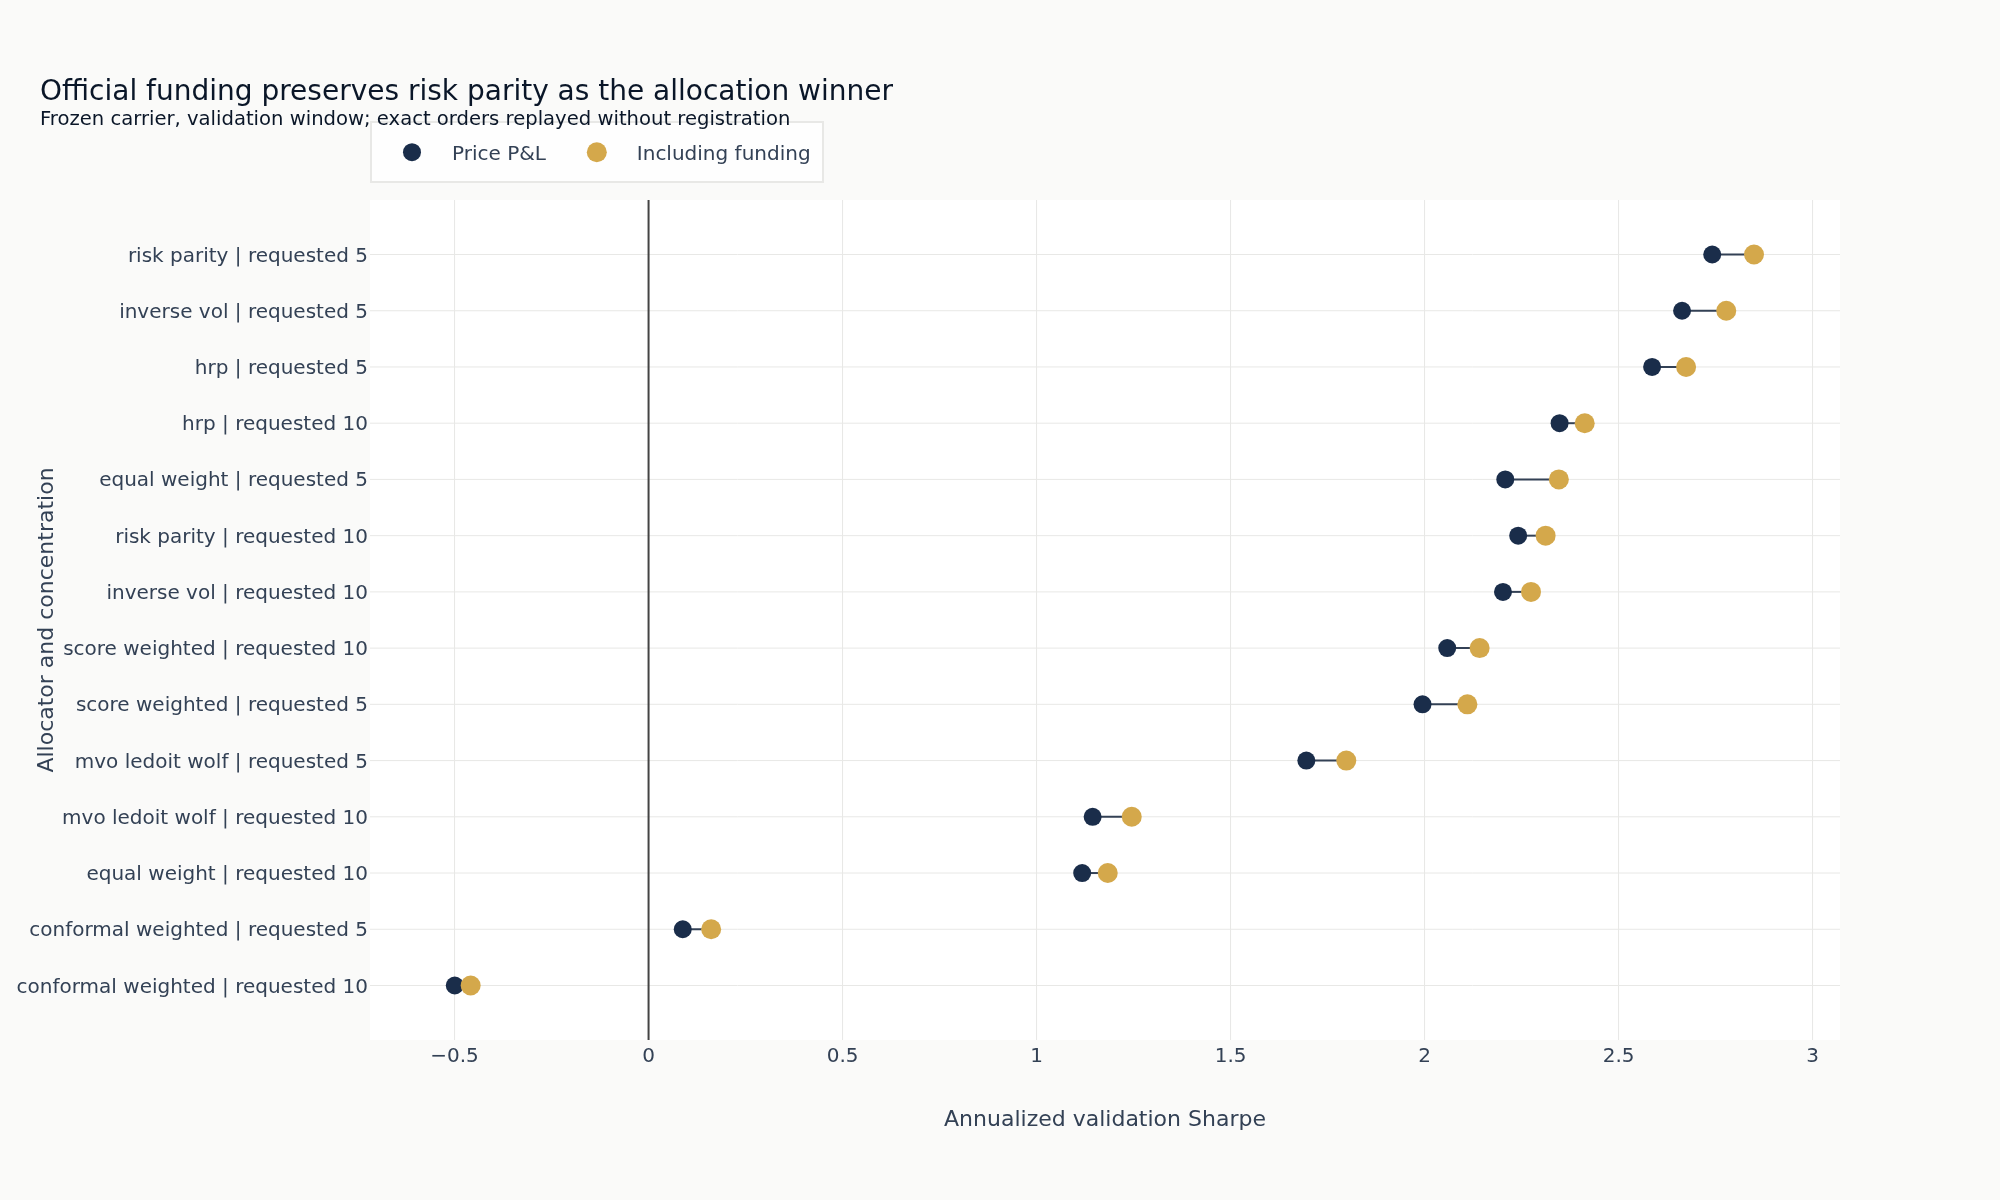

In [24]:
fig.add_trace(
    go.Scatter(
        x=ordered["price_only_sharpe"],
        y=labels,
        mode="markers",
        marker={"size": 9, "color": COLORS["slate"]},
        name="Price P&L",
    )
)
fig.add_trace(
    go.Scatter(
        x=ordered["with_funding_sharpe"],
        y=labels,
        mode="markers",
        marker={"size": 10, "color": COLORS["amber"]},
        name="Including funding",
    )
)
fig.update_layout(
    title={
        "text": "Official funding preserves risk parity as the allocation winner"
        "<br><sup>Frozen carrier, validation window; exact orders replayed without registration</sup>",
        "x": 0.02,
        "xanchor": "left",
    },
    xaxis_title="Annualized validation Sharpe",
    yaxis_title="Allocator and concentration",
    margin={"l": 185},
    legend={"orientation": "h", "yanchor": "bottom", "y": 1.02, "x": 0},
)
fig.show()

## Key takeaways

1. The frozen allocation cohort selects the GBM 24-hour return carrier; the other label leaders do
   not clear zero after selection uncertainty.
2. Risk parity with five requested positions leads both the frozen price-only sweep and the
   corrected funding-inclusive replay, although the two Sharpe values are not directly identical.
3. Allocation is not merely cosmetic: weighting changes both directional P&L and the signed
   funding exposure carried into each settlement.
4. Requested top-k is dynamically capped at half the available panel, repairing early top-5
   timestamps and every top-10 timestamp without dropping registered cells.
5. Point-in-time conformal sizing omits the earliest validation fold and is not competitive on the
   remaining fold; future-fold calibration must never be used to fill that gap.
6. The registry remains a frozen v3.0 price-P&L record. Funding-inclusive values here are
   historical diagnostics; the current v3.1 carrier is selected on a separate 24-hour surface.
7. The next notebook measures cost sensitivity on the same frozen carrier without rewriting the
   registry.